In [2]:
!pip install -U protobuf tensorflow-datasets tensorflow-metadata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.


In [1]:
# ============================================================
# BLOCK 1: IMPORT LIBRARIES AND CHECK ENVIRONMENT
# ============================================================

import os
import time
import random
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image settings
IMG_SIZE = (224, 224)

NUM_CLASSES = 37

# Quick testing mode
QUICK_RUN = False

if QUICK_RUN:
    EPOCHS = 2
    STEPS_PER_EPOCH = 50
    VALIDATION_STEPS = 20
else:
    EPOCHS = 8
    STEPS_PER_EPOCH = None
    VALIDATION_STEPS = None

# Hyperparameters
BATCH_SIZES = [16, 32, 64]

LEARNING_RATES = [
    0.001,
    0.0001
]

DROPOUT_RATES = [
    0.0,
    0.25,
    0.5
]

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)
print("TFDS version:", tfds.__version__)

print(
    "GPU:",
    tf.config.list_physical_devices("GPU")
)

print("\nSetup completed successfully.")

TensorFlow version: 2.20.0
TFDS version: 4.9.10
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Setup completed successfully.


In [2]:
# ============================================================
# BLOCK 2: CHECK TENSORFLOW DATASETS
# ============================================================

print("TFDS version:", tfds.__version__)

print(
    "TFDS location:",
    tfds.__file__
)

print(
    "tfds.load available:",
    hasattr(tfds, "load")
)

if not hasattr(tfds, "load"):

    raise RuntimeError(
        "tfds.load is still unavailable. "
        "Restart the Colab session and run Block 1 again."
    )

print("\nTFDS is working correctly.")

TFDS version: 4.9.10
TFDS location: /usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py
tfds.load available: True

TFDS is working correctly.


In [3]:
# ============================================================
# BLOCK 3: LOAD OXFORD-IIIT PET DATASET
# ============================================================

# Install missing dependency
!pip install -q importlib_resources

print("Loading Oxford-IIIT Pet dataset...")

(train_raw, test_raw), info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)


# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

class_names = info.features["label"].names


# ------------------------------------------------------------
# Dataset information
# ------------------------------------------------------------

print("\nDataset loaded successfully!")

print(
    "Number of classes:",
    len(class_names)
)

print(
    "Training images:",
    info.splits["train"].num_examples
)

print(
    "Testing images:",
    info.splits["test"].num_examples
)


print("\nFirst 10 classes:")

for i in range(min(10, len(class_names))):

    print(
        i,
        ":",
        class_names[i]
    )

Loading Oxford-IIIT Pet dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.

Dataset loaded successfully!
Number of classes: 37
Training images: 3680
Testing images: 3669

First 10 classes:
0 : Abyssinian
1 : american_bulldog
2 : american_pit_bull_terrier
3 : basset_hound
4 : beagle
5 : Bengal
6 : Birman
7 : Bombay
8 : boxer
9 : British_Shorthair


In [4]:
# ============================================================
# BLOCK 4: EXTRACT LABELS
# ============================================================

print("Extracting training labels...")

train_labels = np.array([
    label
    for image, label in tfds.as_numpy(train_raw)
])

print("Extracting test labels...")

test_labels = np.array([
    label
    for image, label in tfds.as_numpy(test_raw)
])

print("\nTraining labels shape:", train_labels.shape)
print("Test labels shape:", test_labels.shape)

print(
    "\nNumber of unique training classes:",
    len(np.unique(train_labels))
)

print(
    "Number of unique test classes:",
    len(np.unique(test_labels))
)

Extracting training labels...
Extracting test labels...

Training labels shape: (3680,)
Test labels shape: (3669,)

Number of unique training classes: 37
Number of unique test classes: 37


In [5]:
# ============================================================
# BLOCK 5: TRAIN / VALIDATION SPLIT
# ============================================================

all_train_indices = np.arange(
    len(train_labels)
)

train_indices, val_indices = train_test_split(
    all_train_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=train_labels
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Independent test samples:", len(test_labels))

print("\nTotal training + validation:",
      len(train_indices) + len(val_indices))

Training samples: 2944
Validation samples: 736
Independent test samples: 3669

Total training + validation: 3680


In [6]:
# ============================================================
# BLOCK 6: IMAGE PREPROCESSING
# ============================================================

def preprocess_image(image, label):

    # Resize image to 224 x 224
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Convert to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # MobileNetV2 preprocessing
    image = preprocess_input(
        image
    )

    return image, label


print("Image preprocessing function created.")

Image preprocessing function created.


In [7]:
# ============================================================
# BLOCK 7: DATASET CREATION FUNCTIONS
# ============================================================

def create_indexed_dataset(
    raw_dataset,
    selected_indices,
    batch_size=32,
    training=False
):

    # Convert selected indices to TensorFlow tensor
    selected_indices = tf.constant(
        selected_indices,
        dtype=tf.int64
    )

    # Add an index to every dataset element
    dataset = raw_dataset.enumerate()

    # Keep only selected indices
    dataset = dataset.filter(
        lambda index, data:
        tf.reduce_any(
            tf.equal(
                index,
                selected_indices
            )
        )
    )

    # Remove the index
    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=AUTOTUNE
    )

    # Resize and preprocess
    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    # Shuffle only training data
    if training:

        dataset = dataset.shuffle(
            1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # Batch
    dataset = dataset.batch(
        batch_size
    )

    # Prefetch
    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


def make_dataset(
    raw_dataset,
    batch_size=32,
    training=False
):

    dataset = raw_dataset.map(
        preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:

        dataset = dataset.shuffle(
            1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


print("Dataset functions created successfully.")

Dataset functions created successfully.


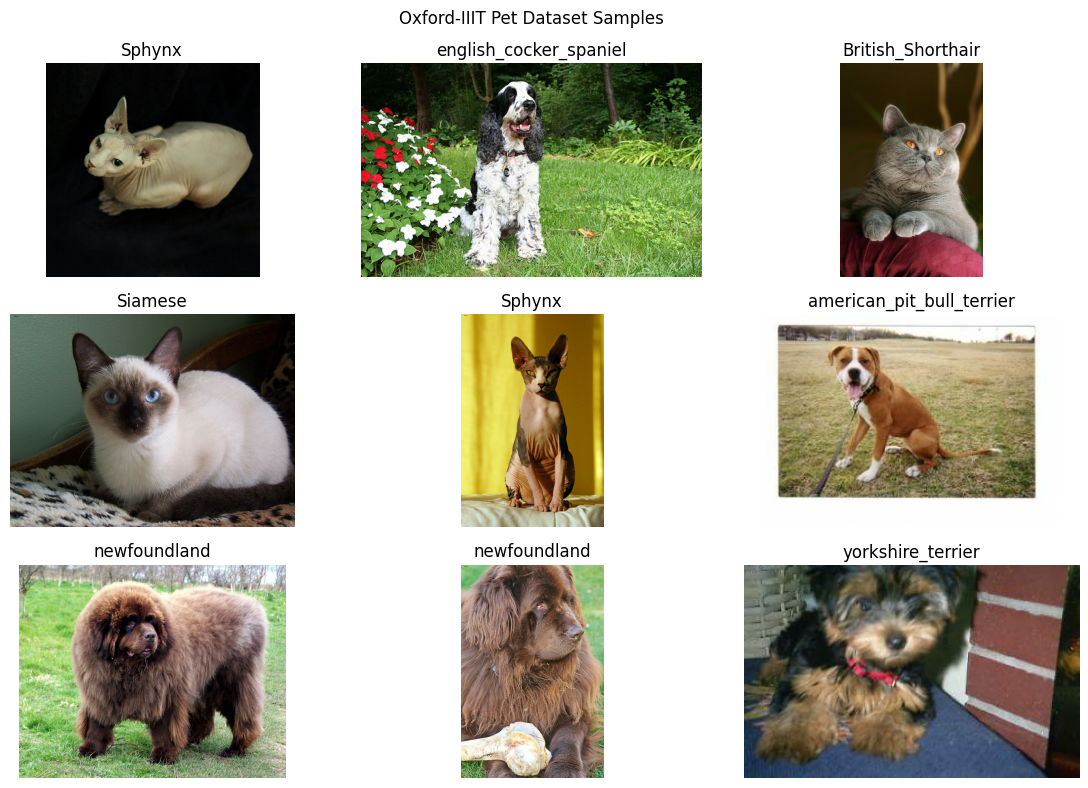

In [8]:
# ============================================================
# BLOCK 8: VISUALIZE SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12, 8))

for i, (image, label) in enumerate(
    train_raw.take(9)
):

    plt.subplot(3, 3, i + 1)

    image = image.numpy()

    plt.imshow(image)

    plt.title(
        class_names[label.numpy()]
    )

    plt.axis("off")

plt.suptitle(
    "Oxford-IIIT Pet Dataset Samples"
)

plt.tight_layout()

plt.show()

In [9]:
# ============================================================
# BLOCK 9: CREATE MOBILENETV2 MODEL
# ============================================================

def create_mobilenet_model(
    num_classes=37,
    weights="imagenet",
    dropout_rate=0.25,
    l2_reg=0.0,
    use_batch_norm=True
):

    # --------------------------------------------------------
    # Load MobileNetV2
    # --------------------------------------------------------

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights=weights
    )

    # Freeze pretrained layers initially
    base_model.trainable = False

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = layers.Input(
        shape=(224, 224, 3)
    )

    # --------------------------------------------------------
    # MobileNetV2 feature extraction
    # --------------------------------------------------------

    x = base_model(
        inputs,
        training=False
    )

    # --------------------------------------------------------
    # Global Average Pooling
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling2D()(x)

    # --------------------------------------------------------
    # Batch Normalization
    # --------------------------------------------------------

    if use_batch_norm:
        x = layers.BatchNormalization()(x)

    # --------------------------------------------------------
    # Dense layer
    # --------------------------------------------------------

    if l2_reg > 0:

        x = layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        )(x)

    else:

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

    # --------------------------------------------------------
    # Dropout
    # --------------------------------------------------------

    if dropout_rate > 0:

        x = layers.Dropout(
            dropout_rate
        )(x)

    # --------------------------------------------------------
    # Output layer
    # --------------------------------------------------------

    if l2_reg > 0:

        outputs = layers.Dense(
            num_classes,
            activation="softmax",
            kernel_regularizer=regularizers.l2(l2_reg)
        )(x)

    else:

        outputs = layers.Dense(
            num_classes,
            activation="softmax"
        )(x)

    # --------------------------------------------------------
    # Complete model
    # --------------------------------------------------------

    model = models.Model(
        inputs,
        outputs
    )

    return model, base_model


print("MobileNetV2 model function created successfully.")

MobileNetV2 model function created successfully.


In [10]:
# ============================================================
# BLOCK 10: CREATE BASELINE MODEL
# ============================================================

baseline_model, baseline_base = create_mobilenet_model(
    num_classes=NUM_CLASSES,
    weights="imagenet",
    dropout_rate=0.25,
    l2_reg=0.0,
    use_batch_norm=True
)

print("Baseline model created.")

print(
    "\nTotal parameters:",
    baseline_model.count_params()
)

print(
    "\nTrainable parameters:"
)

for layer in baseline_model.layers:

    if layer.trainable:

        print(
            layer.name,
            "->",
            layer.count_params()
        )

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Baseline model created.

Total parameters: 2431845

Trainable parameters:
input_layer_1 -> 0
global_average_pooling2d -> 0
batch_normalization -> 5120
dense -> 163968
dropout -> 0
dense_1 -> 4773


In [11]:
# ============================================================
# BLOCK 11: OPTIMIZER FUNCTION
# ============================================================

def get_optimizer(
    name,
    learning_rate=0.001
):

    name = name.lower()

    if name == "sgd":

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif name == "momentum":

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    elif name == "rmsprop":

        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    elif name == "adam":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    else:

        raise ValueError(
            "Unknown optimizer: " + name
        )

    return optimizer


print("Optimizer function created successfully.")

Optimizer function created successfully.


In [12]:
# ============================================================
# BLOCK 12: TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    train_dataset,
    val_dataset=None,
    optimizer_name="adam",
    learning_rate=0.001,
    use_early_stopping=True
):

    # --------------------------------------------------------
    # Create optimizer
    # --------------------------------------------------------

    optimizer = get_optimizer(
        optimizer_name,
        learning_rate
    )

    # --------------------------------------------------------
    # Compile model
    # --------------------------------------------------------

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = []

    if (
        use_early_stopping
        and
        val_dataset is not None
    ):

        callbacks.append(
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            )
        )

    # --------------------------------------------------------
    # Start timer
    # --------------------------------------------------------

    start_time = time.time()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    if val_dataset is not None:

        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=EPOCHS,
            steps_per_epoch=STEPS_PER_EPOCH,
            validation_steps=VALIDATION_STEPS,
            callbacks=callbacks,
            verbose=1
        )

    else:

        history = model.fit(
            train_dataset,
            epochs=EPOCHS,
            steps_per_epoch=STEPS_PER_EPOCH,
            callbacks=callbacks,
            verbose=1
        )

    # --------------------------------------------------------
    # Training time
    # --------------------------------------------------------

    elapsed_time = time.time() - start_time

    return history, elapsed_time


print("Training function created successfully.")

Training function created successfully.


In [13]:
# ============================================================
# BLOCK 13: CREATE BASELINE DATASETS
# ============================================================

baseline_train_ds = create_indexed_dataset(
    train_raw,
    train_indices,
    batch_size=32,
    training=True
)

baseline_val_ds = create_indexed_dataset(
    train_raw,
    val_indices,
    batch_size=32,
    training=False
)

print("Baseline training dataset created.")
print("Baseline validation dataset created.")

Baseline training dataset created.
Baseline validation dataset created.


In [14]:
# ============================================================
# BLOCK 14: TRAIN BASELINE MODEL
# ============================================================

print("=" * 70)
print("TRAINING BASELINE MODEL")
print("=" * 70)

baseline_history, baseline_time = train_model(
    baseline_model,
    baseline_train_ds,
    baseline_val_ds,
    optimizer_name="adam",
    learning_rate=0.001
)

baseline_best_accuracy = (
    max(
        baseline_history.history["val_accuracy"]
    ) * 100
)

print("\n" + "=" * 70)

print(
    "Best Validation Accuracy:",
    round(
        baseline_best_accuracy,
        2
    ),
    "%"
)

print(
    "Training Time:",
    round(
        baseline_time,
        2
    ),
    "seconds"
)

print("=" * 70)

TRAINING BASELINE MODEL
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 233ms/step - accuracy: 0.6831 - loss: 1.1027 - val_accuracy: 0.8777 - val_loss: 0.5120
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.9134 - loss: 0.2775 - val_accuracy: 0.8859 - val_loss: 0.3629
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 201ms/step - accuracy: 0.9474 - loss: 0.1626 - val_accuracy: 0.8927 - val_loss: 0.3257
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.9637 - loss: 0.1158 - val_accuracy: 0.8927 - val_loss: 0.3313
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 180ms/step - accuracy: 0.9796 - loss: 0.0739 - val_accuracy: 0.9049 - val_loss: 0.3241
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 174ms/step - accuracy: 0.9834 - loss: 0.0596 - val_accuracy: 0.9049 - val_loss: 0.3140
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.9844 - loss: 0.0516 - val_accuracy: 0.8981 - val_loss: 0.3309
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.9898 - loss: 0

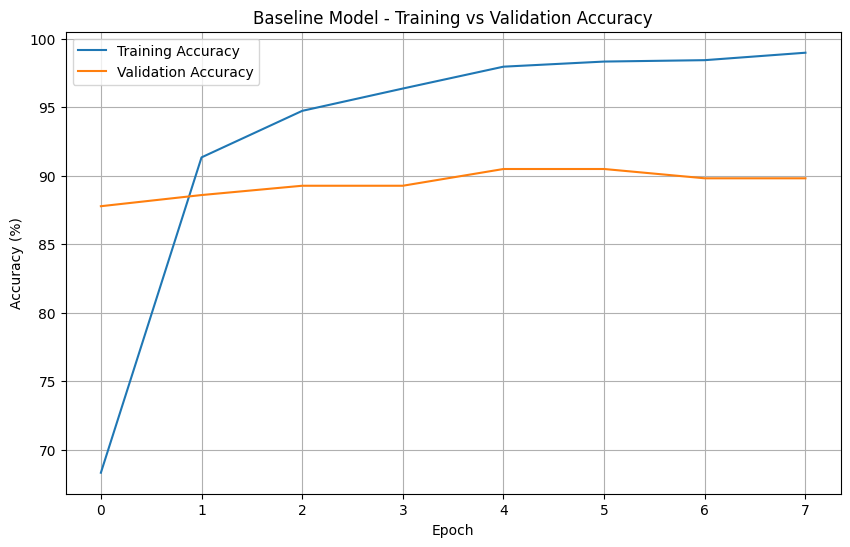

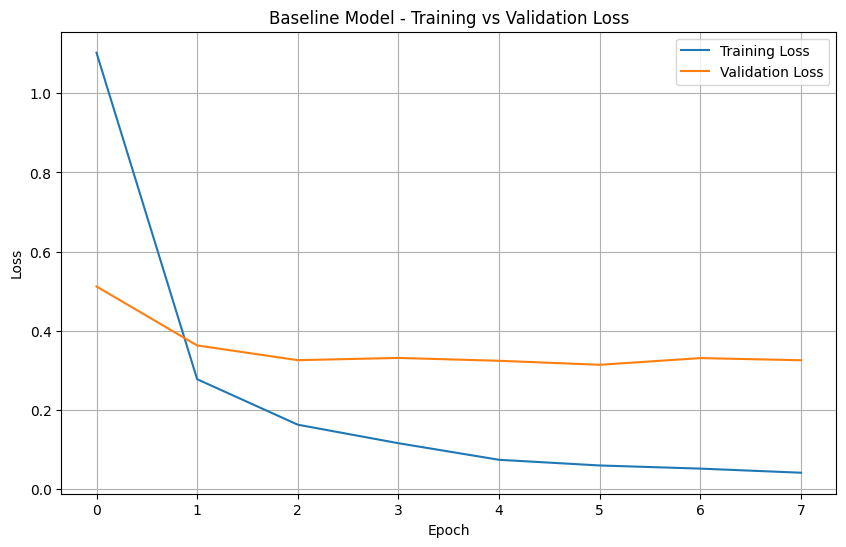

In [15]:
# ============================================================
# BLOCK 15: BASELINE TRAINING PLOTS
# ============================================================

# ------------------------------------------------------------
# Plot 1: Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    np.array(
        baseline_history.history["accuracy"]
    ) * 100,
    label="Training Accuracy"
)

plt.plot(
    np.array(
        baseline_history.history["val_accuracy"]
    ) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Baseline Model - Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# Plot 2: Loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Baseline Model - Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [16]:
# ============================================================
# BLOCK 16: WEIGHT INITIALIZATION FUNCTION
# ============================================================

def initialize_weights(model, method):

    for layer in model.layers:

        # Skip Batch Normalization
        if isinstance(layer, layers.BatchNormalization):
            continue

        # ----------------------------------------------------
        # Kernel weights
        # ----------------------------------------------------

        if hasattr(layer, "kernel") and layer.kernel is not None:

            shape = layer.kernel.shape

            if method == "zero":

                initializer = tf.keras.initializers.Zeros()

            elif method == "random":

                initializer = tf.keras.initializers.RandomNormal(
                    mean=0.0,
                    stddev=0.05,
                    seed=SEED
                )

            elif method == "glorot":

                initializer = tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )

            elif method == "he":

                initializer = tf.keras.initializers.HeNormal(
                    seed=SEED
                )

            else:

                raise ValueError(
                    "Unknown initialization method: "
                    + method
                )

            layer.kernel.assign(
                initializer(shape)
            )

        # ----------------------------------------------------
        # Bias
        # ----------------------------------------------------

        if hasattr(layer, "bias") and layer.bias is not None:

            layer.bias.assign(
                tf.zeros_like(layer.bias)
            )


print("Weight initialization function created.")

Weight initialization function created.


In [17]:
# ============================================================
# BLOCK 17: INITIALIZATION METHODS
# ============================================================

initialization_methods = [
    "zero",
    "random",
    "glorot",
    "he"
]

initialization_histories = {}

initialization_results = {}

print("Initialization methods:")

for method in initialization_methods:
    print("-", method)

Initialization methods:
- zero
- random
- glorot
- he


In [18]:
# ============================================================
# BLOCK 18: WEIGHT INITIALIZATION EXPERIMENT
# ============================================================

for method in initialization_methods:

    print("\n")
    print("=" * 70)
    print("INITIALIZATION:", method.upper())
    print("=" * 70)

    # --------------------------------------------------------
    # Create model WITHOUT ImageNet weights
    # --------------------------------------------------------

    model, base_model = create_mobilenet_model(
        num_classes=NUM_CLASSES,
        weights=None,
        dropout_rate=0.25,
        l2_reg=0.0,
        use_batch_norm=True
    )

    # --------------------------------------------------------
    # Make the complete CNN trainable
    # --------------------------------------------------------

    model.trainable = True

    # --------------------------------------------------------
    # Apply initialization
    # --------------------------------------------------------

    initialize_weights(
        model,
        method
    )

    # --------------------------------------------------------
    # Create datasets
    # --------------------------------------------------------

    train_ds = create_indexed_dataset(
        train_raw,
        train_indices,
        batch_size=32,
        training=True
    )

    val_ds = create_indexed_dataset(
        train_raw,
        val_indices,
        batch_size=32,
        training=False
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history, elapsed = train_model(
        model,
        train_ds,
        val_ds,
        optimizer_name="adam",
        learning_rate=0.001
    )

    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    initialization_histories[
        method
    ] = history

    # --------------------------------------------------------
    # Best validation accuracy
    # --------------------------------------------------------

    best_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    initialization_results[
        method
    ] = {
        "Best Validation Accuracy (%)":
            best_accuracy,

        "Training Time (seconds)":
            elapsed
    }

    print(
        f"\n{method.upper()} Best Validation Accuracy: "
        f"{best_accuracy:.2f}%"
    )

    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    gc.collect()

    tf.keras.backend.clear_session()


print("\nWeight initialization experiment completed.")



INITIALIZATION: ZERO
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 227ms/step - accuracy: 0.0231 - loss: 3.6114 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - accuracy: 0.0207 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.0160 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 159ms/step - accuracy: 0.0211 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.0197 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step - accuracy: 0.0221 - loss: 3.6112 - val_accuracy: 0.0272 - val_loss: 3.6108
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.0228 - loss: 3.6112 - val_accuracy: 0.0272 - val_loss: 3.6108
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 193ms/step - accuracy: 0.0194 - loss: 3.

In [19]:
# ============================================================
# BLOCK 19: INITIALIZATION RESULTS
# ============================================================

initialization_df = pd.DataFrame.from_dict(
    initialization_results,
    orient="index"
)

initialization_df.index.name = "Initialization"

initialization_df = initialization_df.reset_index()

display(
    initialization_df
)

,Initialization,Best Validation Accuracy (%),Training Time (seconds)
0,zero,2.717391,168.363676
1,random,2.717391,150.418796
2,glorot,2.717391,181.623346
3,he,2.717391,165.369316


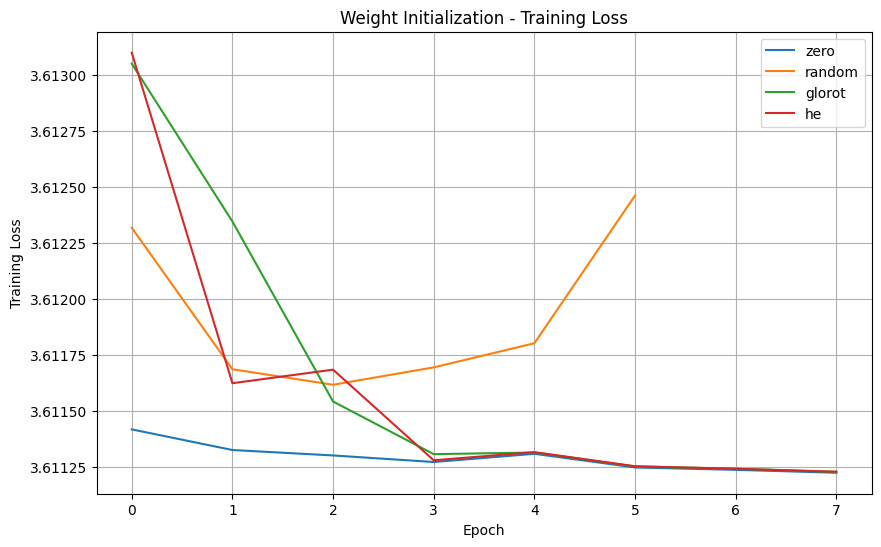

In [20]:
# ============================================================
# BLOCK 20: INITIALIZATION - TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for method, history in initialization_histories.items():

    plt.plot(
        history.history["loss"],
        label=method
    )

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Weight Initialization - Training Loss"
)

plt.legend()

plt.grid(True)

plt.show()

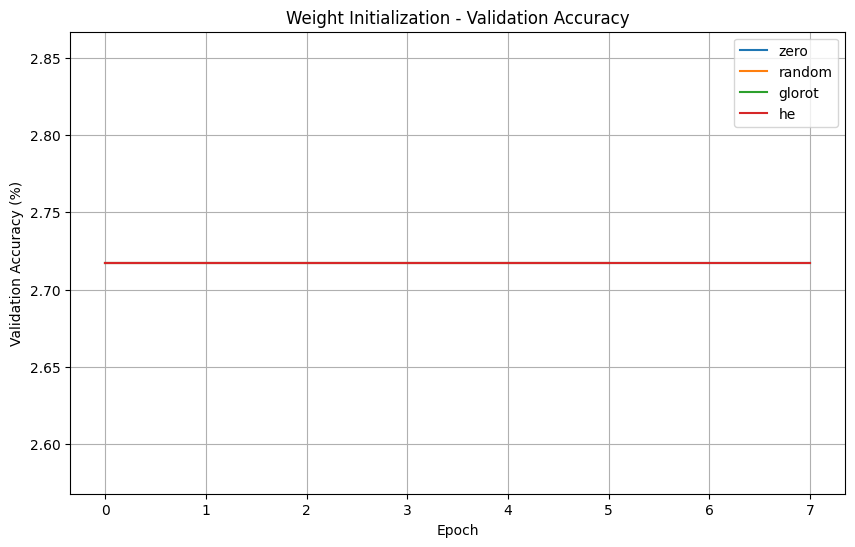

In [21]:
# ============================================================
# BLOCK 21: INITIALIZATION - VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for method, history in initialization_histories.items():

    plt.plot(
        np.array(
            history.history["val_accuracy"]
        ) * 100,
        label=method
    )

plt.xlabel("Epoch")

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Weight Initialization - Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

In [22]:
# ============================================================
# BLOCK 22: BEST INITIALIZATION
# ============================================================

best_initialization = max(
    initialization_results,
    key=lambda x:
    initialization_results[x][
        "Best Validation Accuracy (%)"
    ]
)

best_initialization_accuracy = (
    initialization_results[
        best_initialization
    ][
        "Best Validation Accuracy (%)"
    ]
)

print("=" * 60)

print(
    "BEST INITIALIZATION:",
    best_initialization.upper()
)

print(
    "Validation Accuracy:",
    round(
        best_initialization_accuracy,
        2
    ),
    "%"
)

print("=" * 60)

BEST INITIALIZATION: ZERO
Validation Accuracy: 2.72 %


In [23]:
# ============================================================
# BLOCK 23: SAVE INITIALIZATION RESULTS
# ============================================================

initialization_df.to_csv(
    "Weight_Initialization_Results.csv",
    index=False
)

print(
    "Weight initialization results saved."
)

Weight initialization results saved.


In [24]:
# ============================================================
# BLOCK 24: REGULARIZATION CONFIGURATIONS
# ============================================================

regularization_configs = {

    "No Regularization": {
        "dropout": 0.0,
        "l2": 0.0,
        "batch_norm": False
    },

    "L2 Regularization": {
        "dropout": 0.0,
        "l2": 0.0001,
        "batch_norm": False
    },

    "Dropout": {
        "dropout": 0.5,
        "l2": 0.0,
        "batch_norm": False
    },

    "Batch Normalization": {
        "dropout": 0.0,
        "l2": 0.0,
        "batch_norm": True
    }
}

print("Regularization configurations:")

for name, config in regularization_configs.items():

    print("\n", name)

    print(config)

Regularization configurations:

 No Regularization
{'dropout': 0.0, 'l2': 0.0, 'batch_norm': False}

 L2 Regularization
{'dropout': 0.0, 'l2': 0.0001, 'batch_norm': False}

 Dropout
{'dropout': 0.5, 'l2': 0.0, 'batch_norm': False}

 Batch Normalization
{'dropout': 0.0, 'l2': 0.0, 'batch_norm': True}


In [25]:
# ============================================================
# BLOCK 25: REGULARIZATION EXPERIMENT
# ============================================================

regularization_histories = {}

regularization_results = {}


for name, config in regularization_configs.items():

    print("\n")
    print("=" * 70)

    print(
        "REGULARIZATION:",
        name.upper()
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    model, base_model = create_mobilenet_model(

        num_classes=NUM_CLASSES,

        weights="imagenet",

        dropout_rate=config["dropout"],

        l2_reg=config["l2"],

        use_batch_norm=config["batch_norm"]
    )


    # --------------------------------------------------------
    # Create training dataset
    # --------------------------------------------------------

    train_ds = create_indexed_dataset(

        train_raw,

        train_indices,

        batch_size=32,

        training=True
    )


    # --------------------------------------------------------
    # Create validation dataset
    # --------------------------------------------------------

    val_ds = create_indexed_dataset(

        train_raw,

        val_indices,

        batch_size=32,

        training=False
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history, elapsed = train_model(

        model,

        train_ds,

        val_ds,

        optimizer_name="adam",

        learning_rate=0.001
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    regularization_histories[
        name
    ] = history


    # --------------------------------------------------------
    # Best validation accuracy
    # --------------------------------------------------------

    best_accuracy = max(

        history.history[
            "val_accuracy"
        ]

    ) * 100


    regularization_results[
        name
    ] = {

        "Best Validation Accuracy (%)":
            best_accuracy,

        "Training Time (seconds)":
            elapsed
    }


    print(
        f"\n{name} Best Validation Accuracy: "
        f"{best_accuracy:.2f}%"
    )


    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    gc.collect()

    tf.keras.backend.clear_session()


print("\nRegularization experiment completed.")



REGULARIZATION: NO REGULARIZATION
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 206ms/step - accuracy: 0.7160 - loss: 1.0917 - val_accuracy: 0.8438 - val_loss: 0.4689
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 165ms/step - accuracy: 0.9341 - loss: 0.2231 - val_accuracy: 0.8913 - val_loss: 0.3544
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.9728 - loss: 0.1155 - val_accuracy: 0.8872 - val_loss: 0.3569
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.9837 - loss: 0.0735 - val_accuracy: 0.8886 - val_loss: 0.3270
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - accuracy: 0.9956 - loss: 0.0367 - val_accuracy: 0.8927 - val_loss: 0.3109
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 216ms/step - accuracy: 0.9969 - loss: 0.0266 - val_accuracy: 0.8967 - val_loss: 0.3064
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 168ms/step - accuracy: 0.9997 - loss: 0.0174 - val_accuracy: 0.8967 - val_loss: 0.2962
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 1.00

In [26]:
# ============================================================
# BLOCK 26: REGULARIZATION RESULTS TABLE
# ============================================================

regularization_df = pd.DataFrame.from_dict(

    regularization_results,

    orient="index"
)

regularization_df.index.name = "Configuration"

regularization_df = (
    regularization_df.reset_index()
)


display(
    regularization_df
)

,Configuration,Best Validation Accuracy (%),Training Time (seconds)
0,No Regularization,90.896738,185.726257
1,L2 Regularization,91.032606,196.771029
2,Dropout,90.896738,165.490689
3,Batch Normalization,90.489131,147.127046


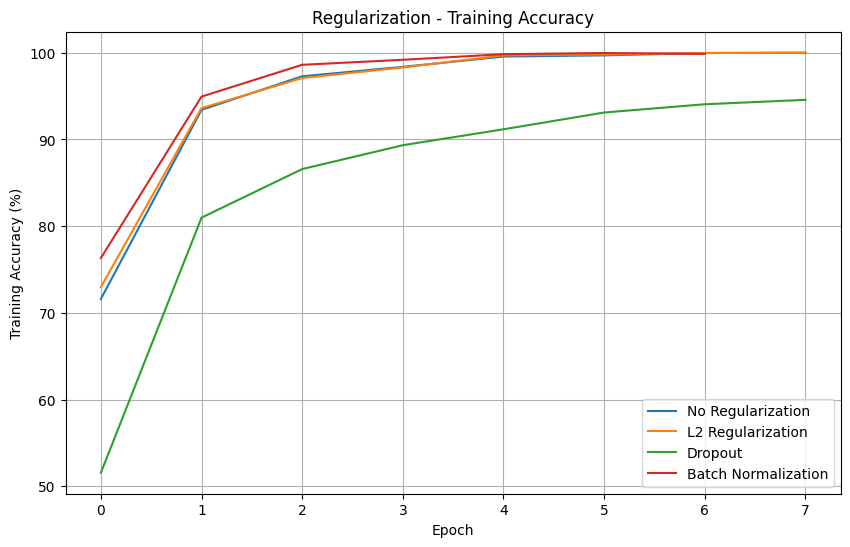

In [27]:
# ============================================================
# BLOCK 27: REGULARIZATION - TRAINING ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for name, history in regularization_histories.items():

    plt.plot(

        np.array(
            history.history["accuracy"]
        ) * 100,

        label=name
    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Accuracy (%)"
)

plt.title(
    "Regularization - Training Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

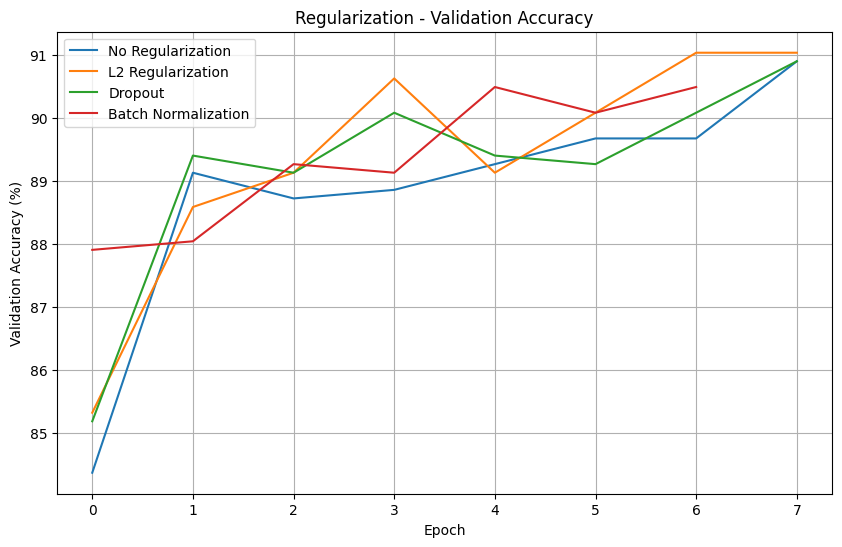

In [28]:
# ============================================================
# BLOCK 28: REGULARIZATION - VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for name, history in regularization_histories.items():

    plt.plot(

        np.array(
            history.history["val_accuracy"]
        ) * 100,

        label=name
    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Regularization - Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

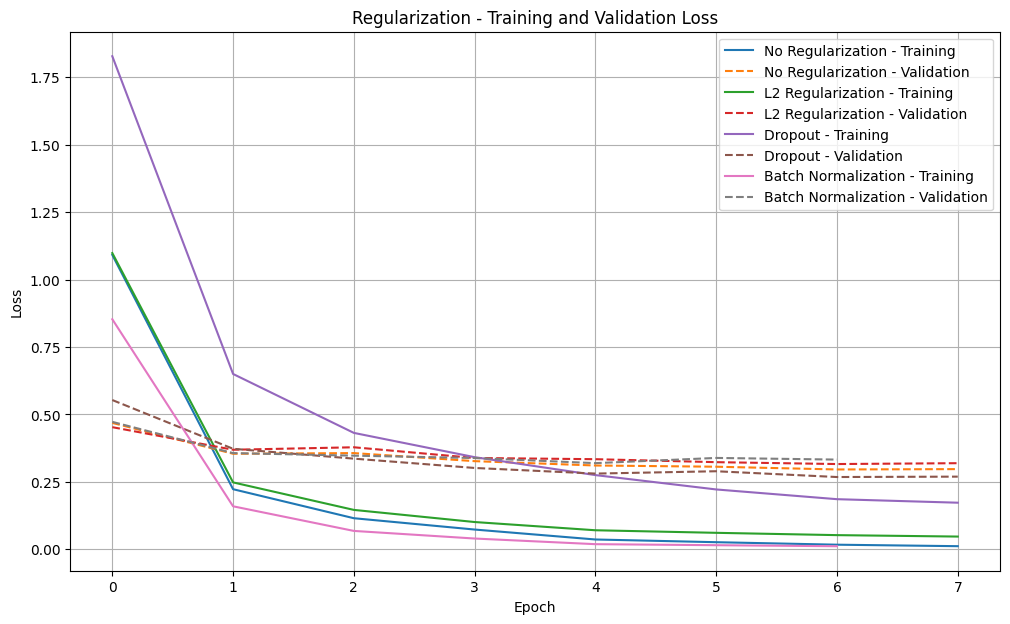

In [29]:
# ============================================================
# BLOCK 29: REGULARIZATION - LOSS COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 7)
)


for name, history in regularization_histories.items():

    plt.plot(

        history.history["loss"],

        label=name + " - Training"
    )


    plt.plot(

        history.history["val_loss"],

        linestyle="--",

        label=name + " - Validation"
    )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Regularization - Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [30]:
# ============================================================
# BLOCK 30: BEST REGULARIZATION
# ============================================================

best_regularization = max(

    regularization_results,

    key=lambda x:
    regularization_results[x][
        "Best Validation Accuracy (%)"
    ]
)


best_regularization_accuracy = (

    regularization_results[
        best_regularization
    ][
        "Best Validation Accuracy (%)"
    ]
)


print("=" * 60)

print(
    "BEST REGULARIZATION:",
    best_regularization
)

print(
    "Validation Accuracy:",
    round(
        best_regularization_accuracy,
        2
    ),
    "%"
)

print("=" * 60)

BEST REGULARIZATION: L2 Regularization
Validation Accuracy: 91.03 %


In [31]:
# ============================================================
# BLOCK 31: SAVE REGULARIZATION RESULTS
# ============================================================

regularization_df.to_csv(

    "Regularization_Results.csv",

    index=False
)


print(
    "Regularization results saved successfully."
)

Regularization results saved successfully.


In [32]:
# ============================================================
# BLOCK 32: BATCH NORMALIZATION NUMERICAL EXAMPLE
# ============================================================

# Input values
x = np.array(
    [2, 4, 6, 8],
    dtype=np.float32
)

# ------------------------------------------------------------
# Step 1: Calculate mean
# ------------------------------------------------------------

mean = np.mean(x)

# ------------------------------------------------------------
# Step 2: Calculate variance
# ------------------------------------------------------------

variance = np.mean(
    (x - mean) ** 2
)

# ------------------------------------------------------------
# Step 3: Epsilon
# ------------------------------------------------------------

epsilon = 1e-5

# ------------------------------------------------------------
# Step 4: Normalize
# ------------------------------------------------------------

x_normalized = (
    x - mean
) / np.sqrt(
    variance + epsilon
)

# ------------------------------------------------------------
# Step 5: Scale and shift
# ------------------------------------------------------------

gamma = 1.0
beta = 0.0

y = (
    gamma * x_normalized
) + beta

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("Input values:")
print(x)

print("\nMean:")
print(mean)

print("\nVariance:")
print(variance)

print("\nNormalized values:")
print(x_normalized)

print("\nGamma:")
print(gamma)

print("\nBeta:")
print(beta)

print("\nFinal Batch Normalization output:")
print(y)

Input values:
[2. 4. 6. 8.]

Mean:
5.0

Variance:
5.0

Normalized values:
[-1.3416395  -0.44721317  0.44721317  1.3416395 ]

Gamma:
1.0

Beta:
0.0

Final Batch Normalization output:
[-1.3416395  -0.44721317  0.44721317  1.3416395 ]


In [33]:
# ============================================================
# BLOCK 33: BATCH NORMALIZATION COMPARISON
# ============================================================

bn_configs = {

    "Without Batch Normalization": False,

    "With Batch Normalization": True

}

bn_histories = {}

bn_results = {}


for name, use_bn in bn_configs.items():

    print("\n")
    print("=" * 70)

    print(name)

    print("=" * 70)

    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    model, base_model = create_mobilenet_model(

        num_classes=NUM_CLASSES,

        weights="imagenet",

        dropout_rate=0.25,

        l2_reg=0.0,

        use_batch_norm=use_bn
    )

    # --------------------------------------------------------
    # Create datasets
    # --------------------------------------------------------

    train_ds = create_indexed_dataset(

        train_raw,

        train_indices,

        batch_size=32,

        training=True
    )

    val_ds = create_indexed_dataset(

        train_raw,

        val_indices,

        batch_size=32,

        training=False
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history, elapsed = train_model(

        model,

        train_ds,

        val_ds,

        optimizer_name="adam",

        learning_rate=0.001
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    bn_histories[name] = history

    best_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    bn_results[name] = {

        "Best Validation Accuracy (%)":
            best_accuracy,

        "Training Time (seconds)":
            elapsed
    }

    print(
        f"\nBest Validation Accuracy: "
        f"{best_accuracy:.2f}%"
    )

    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    gc.collect()

    tf.keras.backend.clear_session()


print("\nBatch Normalization comparison completed.")



Without Batch Normalization
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 233ms/step - accuracy: 0.6294 - loss: 1.3838 - val_accuracy: 0.8709 - val_loss: 0.4439
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.8910 - loss: 0.3643 - val_accuracy: 0.9022 - val_loss: 0.3479
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.9226 - loss: 0.2533 - val_accuracy: 0.9008 - val_loss: 0.3513
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.9494 - loss: 0.1558 - val_accuracy: 0.9076 - val_loss: 0.3369
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.9660 - loss: 0.1171 - val_accuracy: 0.9103 - val_loss: 0.3010
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.9786 - loss: 0.0837 - val_accuracy: 0.9103 - val_loss: 0.2897
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.9823 - loss: 0.0675 - val_accuracy: 0.9171 - val_loss: 0.2803
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 164ms/step - accuracy: 0.9915 - l

In [34]:
# ============================================================
# BLOCK 34: BATCH NORMALIZATION RESULTS
# ============================================================

bn_df = pd.DataFrame.from_dict(

    bn_results,

    orient="index"
)

bn_df.index.name = "Configuration"

bn_df = bn_df.reset_index()

display(bn_df)

,Configuration,Best Validation Accuracy (%),Training Time (seconds)
0,Without Batch Normalization,91.711956,168.633451
1,With Batch Normalization,89.809781,149.525688


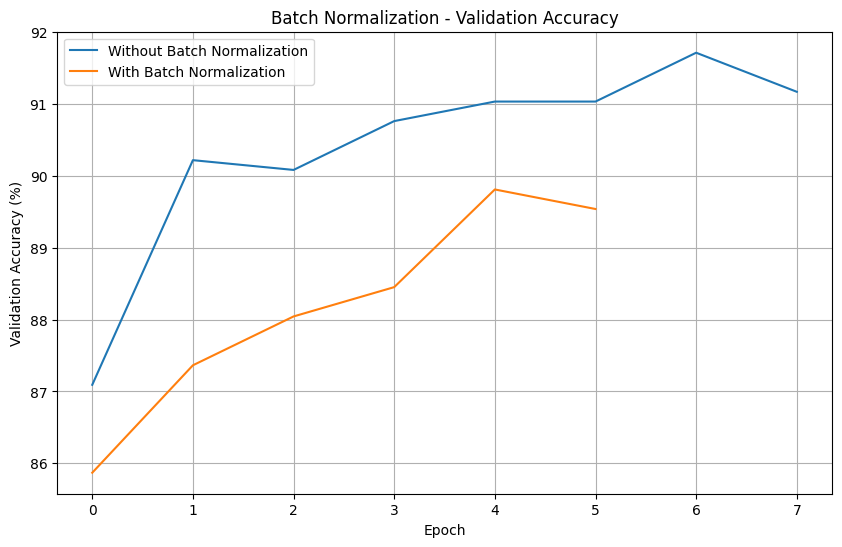

In [35]:
# ============================================================
# BLOCK 35: PLOT - BATCH NORMALIZATION ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for name, history in bn_histories.items():

    plt.plot(

        np.array(
            history.history["val_accuracy"]
        ) * 100,

        label=name
    )

plt.xlabel("Epoch")

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Batch Normalization - Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

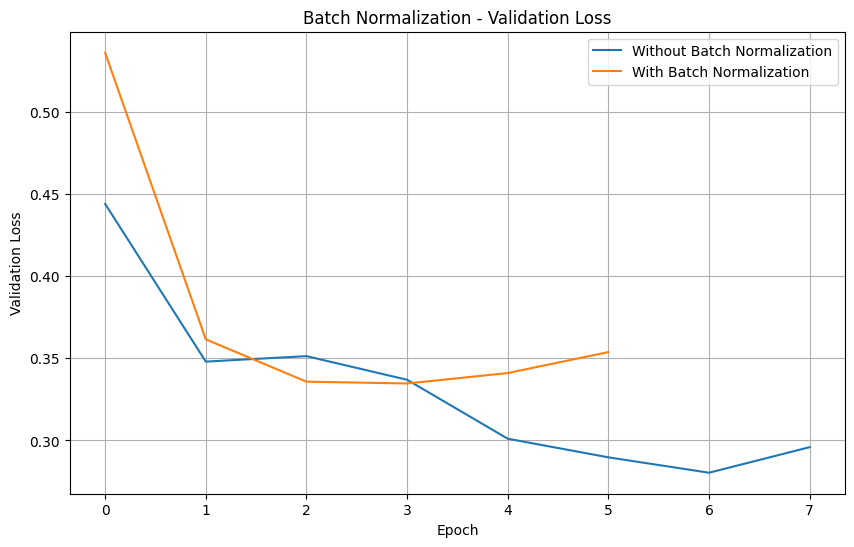

In [36]:
# ============================================================
# BLOCK 36: PLOT - BATCH NORMALIZATION LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for name, history in bn_histories.items():

    plt.plot(

        history.history["val_loss"],

        label=name
    )

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title(
    "Batch Normalization - Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [37]:
# ============================================================
# BLOCK 37: BEST BATCH NORMALIZATION CONFIGURATION
# ============================================================

best_bn = max(

    bn_results,

    key=lambda x:
    bn_results[x][
        "Best Validation Accuracy (%)"
    ]
)

best_bn_accuracy = (

    bn_results[
        best_bn
    ][
        "Best Validation Accuracy (%)"
    ]
)

print("=" * 60)

print(
    "BEST CONFIGURATION:",
    best_bn
)

print(
    "Validation Accuracy:",
    round(
        best_bn_accuracy,
        2
    ),
    "%"
)

print("=" * 60)

BEST CONFIGURATION: Without Batch Normalization
Validation Accuracy: 91.71 %


In [38]:
# ============================================================
# BLOCK 38: SAVE BATCH NORMALIZATION RESULTS
# ============================================================

bn_df.to_csv(

    "Batch_Normalization_Results.csv",

    index=False
)

print(
    "Batch Normalization results saved."
)

Batch Normalization results saved.


In [39]:
# ============================================================
# BLOCK 39: OPTIMIZER EXPERIMENT SETUP
# ============================================================

optimizer_names = [
    "sgd",
    "momentum",
    "rmsprop",
    "adam"
]

optimizer_histories = {}
optimizer_times = {}
optimizer_results = {}

print("Optimizers to compare:")

for optimizer_name in optimizer_names:
    print("-", optimizer_name.upper())

Optimizers to compare:
- SGD
- MOMENTUM
- RMSPROP
- ADAM


In [40]:
# ============================================================
# BLOCK 40: OPTIMIZER COMPARISON
# ============================================================

for optimizer_name in optimizer_names:

    print("\n")
    print("=" * 70)

    print(
        "OPTIMIZER:",
        optimizer_name.upper()
    )

    print("=" * 70)

    # --------------------------------------------------------
    # Create a fresh model
    # --------------------------------------------------------

    model, base_model = create_mobilenet_model(

        num_classes=NUM_CLASSES,

        weights="imagenet",

        dropout_rate=0.25,

        l2_reg=0.0,

        use_batch_norm=True
    )

    # --------------------------------------------------------
    # Create datasets
    # --------------------------------------------------------

    train_ds = create_indexed_dataset(

        train_raw,

        train_indices,

        batch_size=32,

        training=True
    )

    val_ds = create_indexed_dataset(

        train_raw,

        val_indices,

        batch_size=32,

        training=False
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history, elapsed = train_model(

        model,

        train_ds,

        val_ds,

        optimizer_name=optimizer_name,

        learning_rate=0.001
    )

    # --------------------------------------------------------
    # Save history and time
    # --------------------------------------------------------

    optimizer_histories[
        optimizer_name
    ] = history

    optimizer_times[
        optimizer_name
    ] = elapsed

    # --------------------------------------------------------
    # Best validation accuracy
    # --------------------------------------------------------

    best_accuracy = max(

        history.history[
            "val_accuracy"
        ]

    ) * 100

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    optimizer_results[
        optimizer_name
    ] = {

        "Best Validation Accuracy (%)":
            best_accuracy,

        "Final Training Loss":
            history.history[
                "loss"
            ][-1],

        "Training Time (seconds)":
            elapsed
    }

    print(
        f"\nBest Validation Accuracy: "
        f"{best_accuracy:.2f}%"
    )

    print(
        f"Training Time: "
        f"{elapsed:.2f} seconds"
    )

    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    gc.collect()

    tf.keras.backend.clear_session()


print("\nOptimizer experiment completed.")



OPTIMIZER: SGD
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 210ms/step - accuracy: 0.0374 - loss: 4.0762 - val_accuracy: 0.0842 - val_loss: 3.4780
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.0842 - loss: 3.6040 - val_accuracy: 0.1807 - val_loss: 3.1118
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - accuracy: 0.1549 - loss: 3.1334 - val_accuracy: 0.2908 - val_loss: 2.7345
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.2459 - loss: 2.7810 - val_accuracy: 0.3954 - val_loss: 2.3931
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.3261 - loss: 2.4518 - val_accuracy: 0.4796 - val_loss: 2.1022
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.4168 - loss: 2.1946 - val_accuracy: 0.5476 - val_loss: 1.8582
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.4728 - loss: 1.9720 - val_accuracy: 0.5938 - val_loss: 1.6545
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.5370 - loss: 1.7878 -

In [41]:
# ============================================================
# BLOCK 41: OPTIMIZER RESULTS TABLE
# ============================================================

optimizer_df = pd.DataFrame.from_dict(

    optimizer_results,

    orient="index"
)

optimizer_df.index.name = "Optimizer"

optimizer_df = (
    optimizer_df.reset_index()
)

display(
    optimizer_df
)

,Optimizer,Best Validation Accuracy (%),Final Training Loss,Training Time (seconds)
0,sgd,65.489131,1.787817,167.586456
1,momentum,90.353262,0.300843,186.335998
2,rmsprop,89.945650,0.053568,128.529206
3,adam,90.081519,0.046129,149.692632


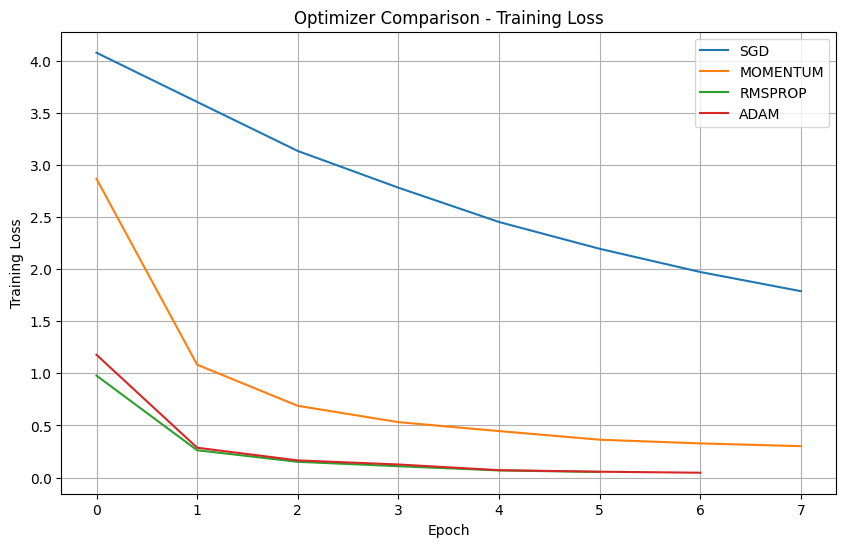

In [42]:
# ============================================================
# BLOCK 42: PLOT - OPTIMIZER TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for optimizer_name, history in optimizer_histories.items():

    plt.plot(

        history.history["loss"],

        label=optimizer_name.upper()
    )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "Optimizer Comparison - Training Loss"
)

plt.legend()

plt.grid(True)

plt.show()

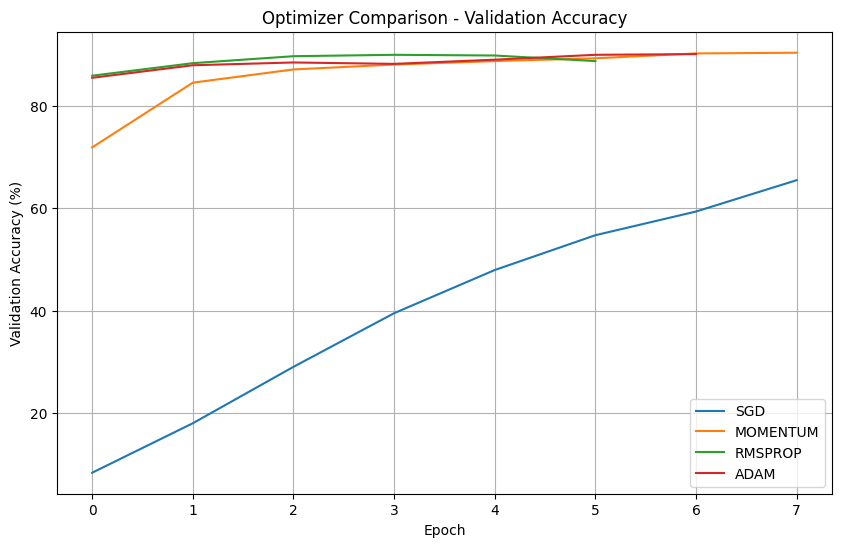

In [43]:
# ============================================================
# BLOCK 43: PLOT - OPTIMIZER VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for optimizer_name, history in optimizer_histories.items():

    plt.plot(

        np.array(
            history.history[
                "val_accuracy"
            ]
        ) * 100,

        label=optimizer_name.upper()
    )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Optimizer Comparison - Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

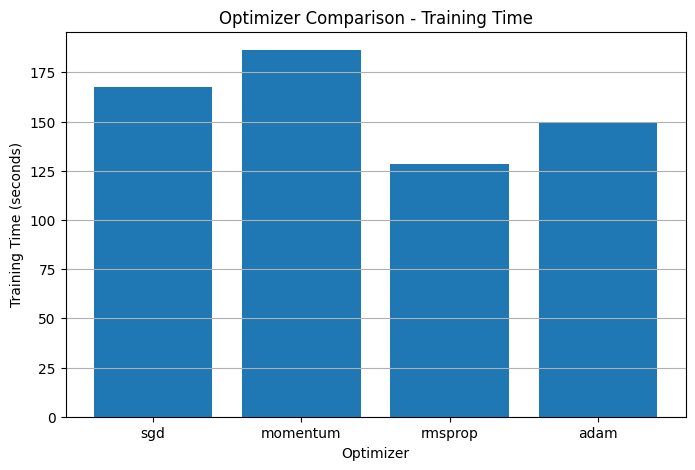

In [44]:
# ============================================================
# BLOCK 44: OPTIMIZER TRAINING TIME
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(

    optimizer_df["Optimizer"],

    optimizer_df[
        "Training Time (seconds)"
    ]
)

plt.xlabel(
    "Optimizer"
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "Optimizer Comparison - Training Time"
)

plt.grid(
    axis="y"
)

plt.show()

In [45]:
# ============================================================
# BLOCK 45: BEST OPTIMIZER
# ============================================================

best_optimizer = max(

    optimizer_results,

    key=lambda x:
    optimizer_results[x][
        "Best Validation Accuracy (%)"
    ]
)

best_optimizer_accuracy = (

    optimizer_results[
        best_optimizer
    ][
        "Best Validation Accuracy (%)"
    ]
)

print("=" * 60)

print(
    "BEST OPTIMIZER:",
    best_optimizer.upper()
)

print(
    "Validation Accuracy:",
    round(
        best_optimizer_accuracy,
        2
    ),
    "%"
)

print("=" * 60)

BEST OPTIMIZER: MOMENTUM
Validation Accuracy: 90.35 %


In [46]:
# ============================================================
# BLOCK 46: SAVE OPTIMIZER RESULTS
# ============================================================

optimizer_df.to_csv(

    "Optimizer_Results.csv",

    index=False
)

print(
    "Optimizer results saved successfully."
)

Optimizer results saved successfully.


In [47]:
# ============================================================
# BLOCK 47: LEARNING RATE TUNING
# ============================================================

learning_rate_results = []

for lr in LEARNING_RATES:

    print("\n")
    print("=" * 70)
    print("LEARNING RATE:", lr)
    print("=" * 70)

    # --------------------------------------------------------
    # Create fresh model
    # --------------------------------------------------------

    model, base_model = create_mobilenet_model(
        num_classes=NUM_CLASSES,
        weights="imagenet",
        dropout_rate=0.25,
        l2_reg=0.0,
        use_batch_norm=True
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_ds = create_indexed_dataset(
        train_raw,
        train_indices,
        batch_size=32,
        training=True
    )

    val_ds = create_indexed_dataset(
        train_raw,
        val_indices,
        batch_size=32,
        training=False
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history, elapsed = train_model(
        model,
        train_ds,
        val_ds,
        optimizer_name="adam",
        learning_rate=lr
    )

    # --------------------------------------------------------
    # Best validation accuracy
    # --------------------------------------------------------

    best_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    learning_rate_results.append({

        "Learning Rate": lr,

        "Best Validation Accuracy (%)":
            best_accuracy,

        "Training Time (seconds)":
            elapsed
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_accuracy:.2f}%"
    )

    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    gc.collect()

    tf.keras.backend.clear_session()


learning_rate_df = pd.DataFrame(
    learning_rate_results
)

display(
    learning_rate_df
)



LEARNING RATE: 0.001
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 216ms/step - accuracy: 0.6899 - loss: 1.1136 - val_accuracy: 0.8709 - val_loss: 0.4813
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 182ms/step - accuracy: 0.9107 - loss: 0.2794 - val_accuracy: 0.8981 - val_loss: 0.3255
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.9446 - loss: 0.1701 - val_accuracy: 0.8981 - val_loss: 0.3099
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 178ms/step - accuracy: 0.9708 - loss: 0.1029 - val_accuracy: 0.9130 - val_loss: 0.3032
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - accuracy: 0.9772 - loss: 0.0779 - val_accuracy: 0.9035 - val_loss: 0.3070
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.9844 - loss: 0.0567 - val_accuracy: 0.9022 - val_loss: 0.3207
Best Validation Accuracy: 91.30%


LEARNING RATE: 0.0001
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 216ms/step - accuracy: 0.1746 - loss: 3.2172 - val_accuracy: 0.4674 - val_loss: 2.3662
Epoch 2/8
92/92 ━━━━━━━━

,Learning Rate,Best Validation Accuracy (%),Training Time (seconds)
0,0.0010,91.304350,129.240279
1,0.0001,88.858694,187.632356


In [48]:
# ============================================================
# BLOCK 49: BEST LEARNING RATE
# ============================================================

best_lr_row = learning_rate_df.loc[
    learning_rate_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]

best_learning_rate = (
    best_lr_row["Learning Rate"]
)

print("=" * 60)

print(
    "BEST LEARNING RATE:",
    best_learning_rate
)

print(
    "Validation Accuracy:",
    round(
        best_lr_row[
            "Best Validation Accuracy (%)"
        ],
        2
    ),
    "%"
)

print("=" * 60)

BEST LEARNING RATE: 0.001
Validation Accuracy: 91.3 %


In [49]:
# ============================================================
# BLOCK 50: BATCH SIZE TUNING
# ============================================================

batch_size_results = []


for batch_size in BATCH_SIZES:

    print("\n")
    print("=" * 70)
    print("BATCH SIZE:", batch_size)
    print("=" * 70)

    # --------------------------------------------------------
    # Create fresh model
    # --------------------------------------------------------

    model, base_model = create_mobilenet_model(
        num_classes=NUM_CLASSES,
        weights="imagenet",
        dropout_rate=0.25,
        l2_reg=0.0,
        use_batch_norm=True
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_ds = create_indexed_dataset(
        train_raw,
        train_indices,
        batch_size=batch_size,
        training=True
    )

    val_ds = create_indexed_dataset(
        train_raw,
        val_indices,
        batch_size=batch_size,
        training=False
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history, elapsed = train_model(
        model,
        train_ds,
        val_ds,
        optimizer_name="adam",
        learning_rate=0.001
    )

    # --------------------------------------------------------
    # Best accuracy
    # --------------------------------------------------------

    best_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    batch_size_results.append({

        "Batch Size": batch_size,

        "Best Validation Accuracy (%)":
            best_accuracy,

        "Training Time (seconds)":
            elapsed
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_accuracy:.2f}%"
    )

    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    gc.collect()

    tf.keras.backend.clear_session()


batch_size_df = pd.DataFrame(
    batch_size_results
)

display(
    batch_size_df
)



BATCH SIZE: 16
Epoch 1/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 121ms/step - accuracy: 0.7014 - loss: 1.0456 - val_accuracy: 0.8709 - val_loss: 0.3994
Epoch 2/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.8984 - loss: 0.3092 - val_accuracy: 0.8804 - val_loss: 0.3532
Epoch 3/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.9293 - loss: 0.1970 - val_accuracy: 0.8791 - val_loss: 0.3801
Epoch 4/8
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9548 - loss: 0.1358 - val_accuracy: 0.8859 - val_loss: 0.3726
Best Validation Accuracy: 88.59%


BATCH SIZE: 32
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 234ms/step - accuracy: 0.6987 - loss: 1.0757 - val_accuracy: 0.8696 - val_loss: 0.5050
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9107 - loss: 0.2716 - val_accuracy: 0.8995 - val_loss: 0.3212
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.9501 - loss: 0.1643 - val_accuracy: 0.8913 - val_loss: 0.3085
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━

,Batch Size,Best Validation Accuracy (%),Training Time (seconds)
0,16,88.586956,123.222553
1,32,90.489131,147.615346
2,64,90.760869,162.527235


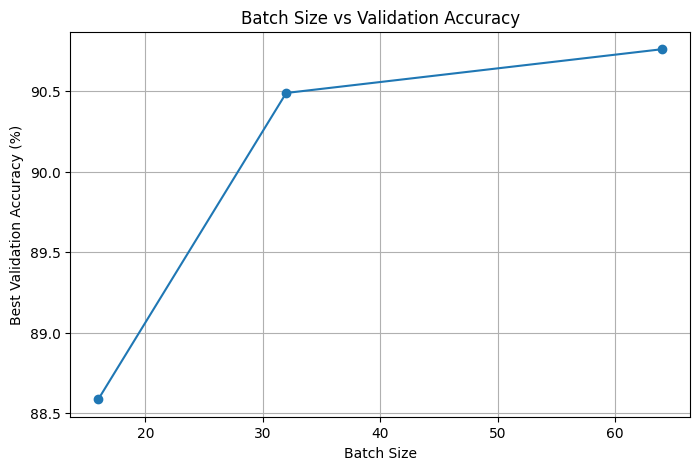

In [50]:
# ============================================================
# BLOCK 51: PLOT - BATCH SIZE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    batch_size_df["Batch Size"],
    batch_size_df[
        "Best Validation Accuracy (%)"
    ],
    marker="o"
)

plt.xlabel(
    "Batch Size"
)

plt.ylabel(
    "Best Validation Accuracy (%)"
)

plt.title(
    "Batch Size vs Validation Accuracy"
)

plt.grid(True)

plt.show()

In [51]:
# ============================================================
# BLOCK 52: BEST BATCH SIZE
# ============================================================

best_batch_row = batch_size_df.loc[
    batch_size_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]

best_batch_size = int(
    best_batch_row["Batch Size"]
)

print("=" * 60)

print(
    "BEST BATCH SIZE:",
    best_batch_size
)

print(
    "Validation Accuracy:",
    round(
        best_batch_row[
            "Best Validation Accuracy (%)"
        ],
        2
    ),
    "%"
)

print("=" * 60)

BEST BATCH SIZE: 64
Validation Accuracy: 90.76 %


In [52]:
# ============================================================
# BLOCK 53: DROPOUT TUNING
# ============================================================

dropout_results = []


for dropout in DROPOUT_RATES:

    print("\n")
    print("=" * 70)
    print("DROPOUT RATE:", dropout)
    print("=" * 70)

    # --------------------------------------------------------
    # Create fresh model
    # --------------------------------------------------------

    model, base_model = create_mobilenet_model(
        num_classes=NUM_CLASSES,
        weights="imagenet",
        dropout_rate=dropout,
        l2_reg=0.0,
        use_batch_norm=True
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_ds = create_indexed_dataset(
        train_raw,
        train_indices,
        batch_size=32,
        training=True
    )

    val_ds = create_indexed_dataset(
        train_raw,
        val_indices,
        batch_size=32,
        training=False
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history, elapsed = train_model(
        model,
        train_ds,
        val_ds,
        optimizer_name="adam",
        learning_rate=0.001
    )

    # --------------------------------------------------------
    # Best accuracy
    # --------------------------------------------------------

    best_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    dropout_results.append({

        "Dropout Rate": dropout,

        "Best Validation Accuracy (%)":
            best_accuracy,

        "Training Time (seconds)":
            elapsed
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_accuracy:.2f}%"
    )

    # --------------------------------------------------------
    # Clear memory
    # --------------------------------------------------------

    del model
    del base_model

    gc.collect()

    tf.keras.backend.clear_session()


dropout_df = pd.DataFrame(
    dropout_results
)

display(
    dropout_df
)



DROPOUT RATE: 0.0
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.7490 - loss: 0.9240 - val_accuracy: 0.8655 - val_loss: 0.5049
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.9545 - loss: 0.1549 - val_accuracy: 0.8872 - val_loss: 0.3568
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.9823 - loss: 0.0723 - val_accuracy: 0.8899 - val_loss: 0.3436
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 173ms/step - accuracy: 0.9949 - loss: 0.0384 - val_accuracy: 0.9022 - val_loss: 0.3291
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.9973 - loss: 0.0206 - val_accuracy: 0.9049 - val_loss: 0.3321
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.9983 - loss: 0.0157 - val_accuracy: 0.9035 - val_loss: 0.3394
Best Validation Accuracy: 90.49%


DROPOUT RATE: 0.25
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 217ms/step - accuracy: 0.6950 - loss: 1.1537 - val_accuracy: 0.8791 - val_loss: 0.4925
Epoch 2/8
92/92 ━━━━━━━━━━━━━━

,Dropout Rate,Best Validation Accuracy (%),Training Time (seconds)
0,0.00,90.489131,129.047129
1,0.25,90.489131,134.388748
2,0.50,90.217394,171.169605


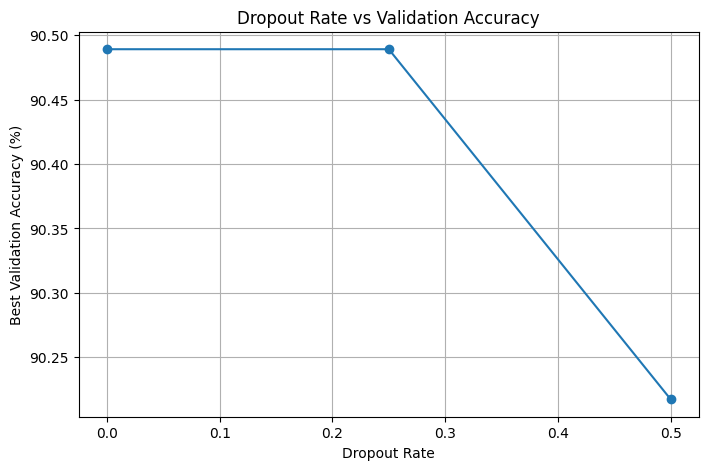

In [53]:
# ============================================================
# BLOCK 54: PLOT - DROPOUT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    dropout_df["Dropout Rate"],
    dropout_df[
        "Best Validation Accuracy (%)"
    ],
    marker="o"
)

plt.xlabel(
    "Dropout Rate"
)

plt.ylabel(
    "Best Validation Accuracy (%)"
)

plt.title(
    "Dropout Rate vs Validation Accuracy"
)

plt.grid(True)

plt.show()

In [54]:
# ============================================================
# BLOCK 55: BEST DROPOUT RATE
# ============================================================

best_dropout_row = dropout_df.loc[
    dropout_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]

best_dropout = float(
    best_dropout_row[
        "Dropout Rate"
    ]
)

print("=" * 60)

print(
    "BEST DROPOUT RATE:",
    best_dropout
)

print(
    "Validation Accuracy:",
    round(
        best_dropout_row[
            "Best Validation Accuracy (%)"
        ],
        2
    ),
    "%"
)

print("=" * 60)

BEST DROPOUT RATE: 0.0
Validation Accuracy: 90.49 %


In [55]:
# ============================================================
# BLOCK 56: HYPERPARAMETER SUMMARY
# ============================================================

hyperparameter_summary = pd.DataFrame({

    "Hyperparameter": [

        "Learning Rate",

        "Batch Size",

        "Dropout Rate"
    ],

    "Best Value": [

        best_learning_rate,

        best_batch_size,

        best_dropout
    ],

    "Best Validation Accuracy (%)": [

        best_lr_row[
            "Best Validation Accuracy (%)"
        ],

        best_batch_row[
            "Best Validation Accuracy (%)"
        ],

        best_dropout_row[
            "Best Validation Accuracy (%)"
        ]
    ]
})


display(
    hyperparameter_summary
)

,Hyperparameter,Best Value,Best Validation Accuracy (%)
0,Learning Rate,0.001,91.304350
1,Batch Size,64.000,90.760869
2,Dropout Rate,0.000,90.489131


In [56]:
# ============================================================
# BLOCK 57: SAVE HYPERPARAMETER RESULTS
# ============================================================

learning_rate_df.to_csv(
    "Learning_Rate_Results.csv",
    index=False
)

batch_size_df.to_csv(
    "Batch_Size_Results.csv",
    index=False
)

dropout_df.to_csv(
    "Dropout_Results.csv",
    index=False
)

hyperparameter_summary.to_csv(
    "Hyperparameter_Summary.csv",
    index=False
)

print(
    "All hyperparameter results saved successfully."
)

All hyperparameter results saved successfully.


In [57]:
# ============================================================
# BLOCK 58: TRANSFER LEARNING - FEATURE EXTRACTION
# ============================================================

print("=" * 70)
print("TRANSFER LEARNING - FEATURE EXTRACTION")
print("=" * 70)

# ------------------------------------------------------------
# Create MobileNetV2 model
# ------------------------------------------------------------

feature_model, feature_base = create_mobilenet_model(
    num_classes=NUM_CLASSES,
    weights="imagenet",
    dropout_rate=best_dropout,
    l2_reg=0.0,
    use_batch_norm=True
)

# ------------------------------------------------------------
# Freeze complete MobileNetV2 base
# ------------------------------------------------------------

feature_base.trainable = False

print(
    "MobileNetV2 base trainable:",
    feature_base.trainable
)

print(
    "Total parameters:",
    feature_model.count_params()
)

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in feature_model.trainable_variables
    )
)

# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

feature_train_ds = create_indexed_dataset(
    train_raw,
    train_indices,
    batch_size=best_batch_size,
    training=True
)

feature_val_ds = create_indexed_dataset(
    train_raw,
    val_indices,
    batch_size=best_batch_size,
    training=False
)

# ------------------------------------------------------------
# Train classifier
# ------------------------------------------------------------

feature_history, feature_time = train_model(
    feature_model,
    feature_train_ds,
    feature_val_ds,
    optimizer_name=best_optimizer,
    learning_rate=best_learning_rate
)

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

feature_best_accuracy = (
    max(
        feature_history.history["val_accuracy"]
    ) * 100
)

print("\nFeature Extraction Results")
print("-" * 50)

print(
    "Best Validation Accuracy:",
    round(feature_best_accuracy, 2),
    "%"
)

print(
    "Training Time:",
    round(feature_time, 2),
    "seconds"
)

TRANSFER LEARNING - FEATURE EXTRACTION
MobileNetV2 base trainable: False
Total parameters: 2431845
Trainable parameters: 171301
Epoch 1/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 35s 513ms/step - accuracy: 0.1321 - loss: 3.4072 - val_accuracy: 0.3261 - val_loss: 2.7717
Epoch 2/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 662ms/step - accuracy: 0.6328 - loss: 1.6746 - val_accuracy: 0.7106 - val_loss: 1.7804
Epoch 3/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 393ms/step - accuracy: 0.8040 - loss: 0.9540 - val_accuracy: 0.7976 - val_loss: 1.1976
Epoch 4/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 333ms/step - accuracy: 0.8635 - loss: 0.6729 - val_accuracy: 0.8370 - val_loss: 0.8802
Epoch 5/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 332ms/step - accuracy: 0.8927 - loss: 0.5262 - val_accuracy: 0.8492 - val_loss: 0.7028
Epoch 6/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 363ms/step - accuracy: 0.9022 - loss: 0.4391 - val_accuracy: 0.8587 - val_loss: 0.6000
Epoch 7/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 348ms/step - accuracy: 0.9134 - loss: 0.3794 - val_accuracy: 0.

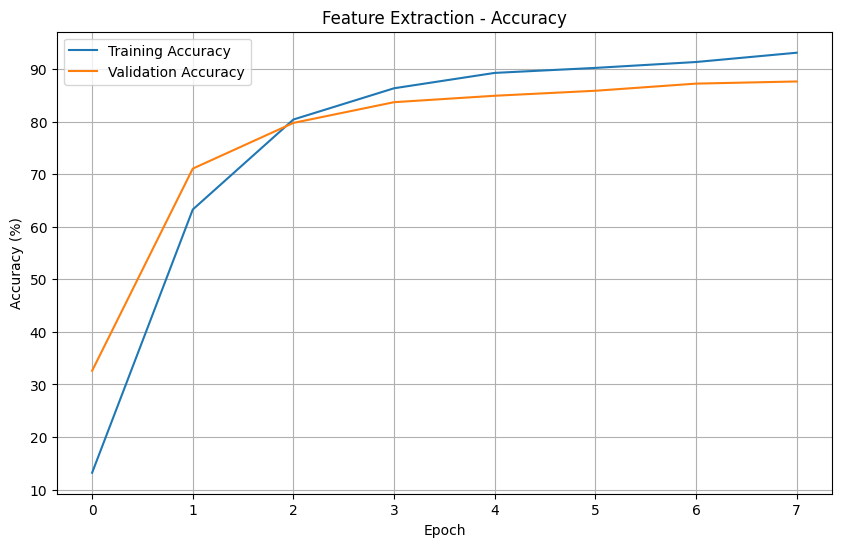

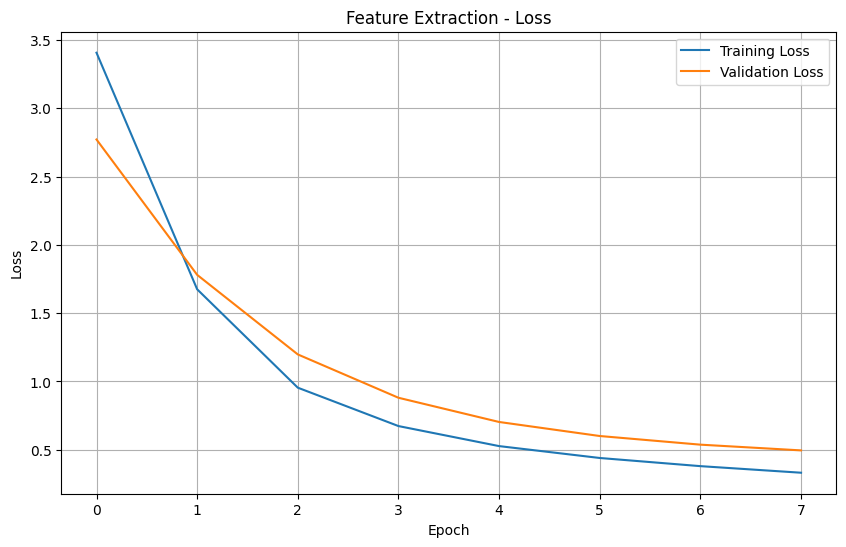

In [58]:
# ============================================================
# BLOCK 59: FEATURE EXTRACTION PLOTS
# ============================================================

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    np.array(
        feature_history.history["accuracy"]
    ) * 100,
    label="Training Accuracy"
)

plt.plot(
    np.array(
        feature_history.history["val_accuracy"]
    ) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Feature Extraction - Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    feature_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    feature_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Feature Extraction - Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [59]:
# ============================================================
# BLOCK 60: TRANSFER LEARNING - FINE-TUNING
# ============================================================

print("=" * 70)
print("TRANSFER LEARNING - FINE-TUNING")
print("=" * 70)

# ------------------------------------------------------------
# Create a fresh pretrained model
# ------------------------------------------------------------

fine_model, fine_base = create_mobilenet_model(
    num_classes=NUM_CLASSES,
    weights="imagenet",
    dropout_rate=best_dropout,
    l2_reg=0.0,
    use_batch_norm=True
)

# ------------------------------------------------------------
# Unfreeze MobileNetV2
# ------------------------------------------------------------

fine_base.trainable = True

# ------------------------------------------------------------
# Freeze lower layers
# ------------------------------------------------------------

fine_tune_from = 100

for layer in fine_base.layers[:fine_tune_from]:
    layer.trainable = False

# ------------------------------------------------------------
# Keep BatchNorm frozen
# ------------------------------------------------------------

for layer in fine_base.layers:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

# ------------------------------------------------------------
# Display trainable status
# ------------------------------------------------------------

trainable_layers = sum(
    1
    for layer in fine_base.layers
    if layer.trainable
)

print(
    "Total MobileNetV2 layers:",
    len(fine_base.layers)
)

print(
    "Trainable MobileNetV2 layers:",
    trainable_layers
)

print(
    "Total model parameters:",
    fine_model.count_params()
)

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in fine_model.trainable_variables
    )
)

TRANSFER LEARNING - FINE-TUNING
Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 36
Total model parameters: 2431845
Trainable parameters: 2010917


In [60]:
# ============================================================
# BLOCK 61: TRAIN FINE-TUNED MODEL
# ============================================================

fine_train_ds = create_indexed_dataset(
    train_raw,
    train_indices,
    batch_size=best_batch_size,
    training=True
)

fine_val_ds = create_indexed_dataset(
    train_raw,
    val_indices,
    batch_size=best_batch_size,
    training=False
)

# ------------------------------------------------------------
# Smaller learning rate for fine-tuning
# ------------------------------------------------------------

fine_tune_learning_rate = 0.00001

fine_history, fine_time = train_model(
    fine_model,
    fine_train_ds,
    fine_val_ds,
    optimizer_name="adam",
    learning_rate=fine_tune_learning_rate
)

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

fine_best_accuracy = (
    max(
        fine_history.history["val_accuracy"]
    ) * 100
)

print("\nFine-Tuning Results")
print("-" * 50)

print(
    "Best Validation Accuracy:",
    round(fine_best_accuracy, 2),
    "%"
)

print(
    "Training Time:",
    round(fine_time, 2),
    "seconds"
)

Epoch 1/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 524ms/step - accuracy: 0.0489 - loss: 3.8067 - val_accuracy: 0.1114 - val_loss: 3.2887
Epoch 2/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 691ms/step - accuracy: 0.2368 - loss: 2.8069 - val_accuracy: 0.2812 - val_loss: 2.7181
Epoch 3/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 348ms/step - accuracy: 0.4929 - loss: 2.0593 - val_accuracy: 0.5082 - val_loss: 2.1389
Epoch 4/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 356ms/step - accuracy: 0.6790 - loss: 1.5313 - val_accuracy: 0.6617 - val_loss: 1.6589
Epoch 5/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 341ms/step - accuracy: 0.7921 - loss: 1.1625 - val_accuracy: 0.7418 - val_loss: 1.3125
Epoch 6/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 356ms/step - accuracy: 0.8424 - loss: 0.9131 - val_accuracy: 0.7853 - val_loss: 1.0726
Epoch 7/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 381ms/step - accuracy: 0.8835 - loss: 0.7484 - val_accuracy: 0.8071 - val_loss: 0.9144
Epoch 8/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 366ms/step - accuracy: 0.9076 - loss: 0.6165 - val_accuracy: 0.

In [61]:
# ============================================================
# BLOCK 62: FEATURE EXTRACTION VS FINE-TUNING
# ============================================================

transfer_results = pd.DataFrame({

    "Method": [
        "Feature Extraction",
        "Fine-Tuning"
    ],

    "Best Validation Accuracy (%)": [
        feature_best_accuracy,
        fine_best_accuracy
    ],

    "Training Time (seconds)": [
        feature_time,
        fine_time
    ]
})

display(
    transfer_results
)

,Method,Best Validation Accuracy (%),Training Time (seconds)
0,Feature Extraction,87.635869,205.337684
1,Fine-Tuning,83.016306,195.485336


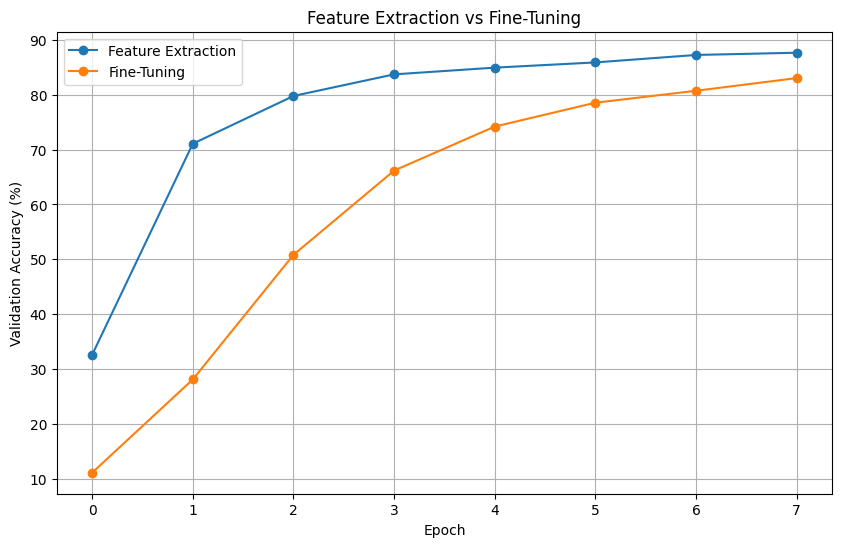

In [62]:
# ============================================================
# BLOCK 63: TRANSFER LEARNING ACCURACY PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    np.array(
        feature_history.history["val_accuracy"]
    ) * 100,
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    np.array(
        fine_history.history["val_accuracy"]
    ) * 100,
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Feature Extraction vs Fine-Tuning"
)

plt.legend()

plt.grid(True)

plt.show()

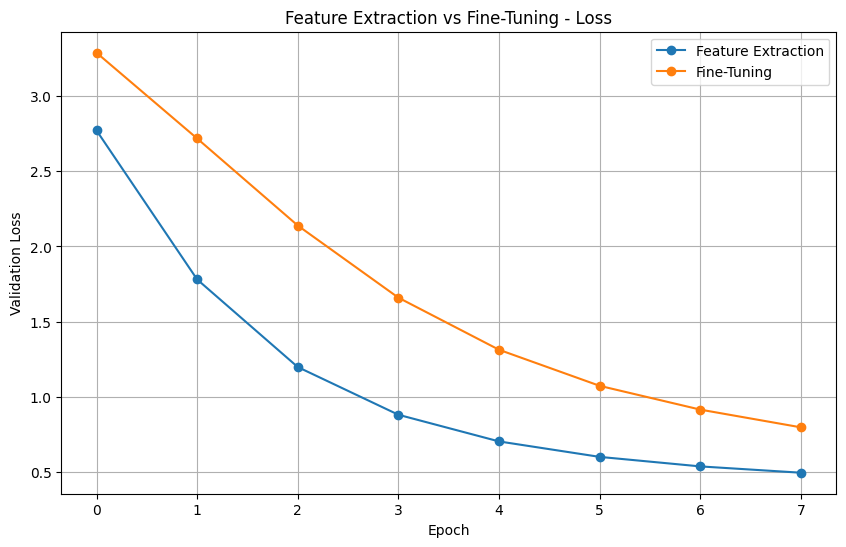

In [63]:
# ============================================================
# BLOCK 64: TRANSFER LEARNING LOSS PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    feature_history.history["val_loss"],
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    fine_history.history["val_loss"],
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")

plt.ylabel(
    "Validation Loss"
)

plt.title(
    "Feature Extraction vs Fine-Tuning - Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [64]:
# ============================================================
# BLOCK 65: BEST TRANSFER LEARNING METHOD
# ============================================================

if fine_best_accuracy > feature_best_accuracy:

    best_transfer_method = "Fine-Tuning"

    best_transfer_accuracy = fine_best_accuracy

else:

    best_transfer_method = "Feature Extraction"

    best_transfer_accuracy = feature_best_accuracy


print("=" * 60)

print(
    "BEST TRANSFER LEARNING METHOD:",
    best_transfer_method
)

print(
    "Validation Accuracy:",
    round(
        best_transfer_accuracy,
        2
    ),
    "%"
)

print("=" * 60)

BEST TRANSFER LEARNING METHOD: Feature Extraction
Validation Accuracy: 87.64 %


In [65]:
# ============================================================
# BLOCK 66: FINAL CANDIDATE CONFIGURATIONS
# ============================================================

candidate_configs = {

    "Candidate_1_Baseline": {

        "learning_rate": 0.001,

        "batch_size": 32,

        "dropout": 0.25,

        "optimizer": "adam",

        "fine_tune": False
    },

    "Candidate_2_Best_LR": {

        "learning_rate": float(
            best_learning_rate
        ),

        "batch_size": 32,

        "dropout": 0.25,

        "optimizer": "adam",

        "fine_tune": False
    },

    "Candidate_3_Best_Dropout": {

        "learning_rate": 0.001,

        "batch_size": 32,

        "dropout": float(
            best_dropout
        ),

        "optimizer": "adam",

        "fine_tune": False
    },

    "Candidate_4_Fine_Tuned": {

        "learning_rate": 0.00001,

        "batch_size": best_batch_size,

        "dropout": float(
            best_dropout
        ),

        "optimizer": "adam",

        "fine_tune": True
    }
}


print("Candidate configurations:")

for name, config in candidate_configs.items():

    print("\n" + name)

    for key, value in config.items():

        print(
            f"  {key}: {value}"
        )

Candidate configurations:

Candidate_1_Baseline
  learning_rate: 0.001
  batch_size: 32
  dropout: 0.25
  optimizer: adam
  fine_tune: False

Candidate_2_Best_LR
  learning_rate: 0.001
  batch_size: 32
  dropout: 0.25
  optimizer: adam
  fine_tune: False

Candidate_3_Best_Dropout
  learning_rate: 0.001
  batch_size: 32
  dropout: 0.0
  optimizer: adam
  fine_tune: False

Candidate_4_Fine_Tuned
  learning_rate: 1e-05
  batch_size: 64
  dropout: 0.0
  optimizer: adam
  fine_tune: True


In [66]:
# ============================================================
# BLOCK 67: BUILD CANDIDATE MODEL
# ============================================================

def build_candidate_model(config):

    model, base_model = create_mobilenet_model(

        num_classes=NUM_CLASSES,

        weights="imagenet",

        dropout_rate=config["dropout"],

        l2_reg=0.0,

        use_batch_norm=True
    )

    # --------------------------------------------------------
    # Feature extraction
    # --------------------------------------------------------

    if config["fine_tune"] is False:

        base_model.trainable = False

    # --------------------------------------------------------
    # Fine-tuning
    # --------------------------------------------------------

    else:

        base_model.trainable = True

        # Freeze lower layers
        for layer in base_model.layers[:100]:

            layer.trainable = False

        # Freeze BatchNorm
        for layer in base_model.layers:

            if isinstance(
                layer,
                layers.BatchNormalization
            ):

                layer.trainable = False

    return model


print("Candidate model function created.")

Candidate model function created.


In [ ]:
# ============================================================
# BLOCK 68: 5-FOLD CROSS-VALIDATION
# ============================================================

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Stratified 5-fold
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_results = []


# ------------------------------------------------------------
# Test every candidate
# ------------------------------------------------------------

for candidate_name, config in candidate_configs.items():

    print("\n")
    print("#" * 70)

    print(
        "CONFIGURATION:",
        candidate_name
    )

    print("#" * 70)

    fold_accuracies = []


    # --------------------------------------------------------
    # Five folds
    # --------------------------------------------------------

    for fold, (
        fold_train_positions,
        fold_val_positions
    ) in enumerate(

        skf.split(
            train_indices,
            train_labels[
                train_indices
            ]
        ),

        start=1
    ):

        print(
            f"\n---------- FOLD {fold}/5 ----------"
        )


        # ----------------------------------------------------
        # Convert positions to actual dataset indices
        # ----------------------------------------------------

        fold_train_indices = (

            train_indices[
                fold_train_positions
            ]

        )


        fold_val_indices = (

            train_indices[
                fold_val_positions
            ]

        )


        # ----------------------------------------------------
        # Create datasets
        # ----------------------------------------------------

        fold_train_ds = create_indexed_dataset(

            train_raw,

            fold_train_indices,

            batch_size=config[
                "batch_size"
            ],

            training=True
        )


        fold_val_ds = create_indexed_dataset(

            train_raw,

            fold_val_indices,

            batch_size=config[
                "batch_size"
            ],

            training=False
        )


        # ----------------------------------------------------
        # Fresh model for every fold
        # ----------------------------------------------------

        model = build_candidate_model(
            config
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        history, elapsed = train_model(

            model,

            fold_train_ds,

            fold_val_ds,

            optimizer_name=config[
                "optimizer"
            ],

            learning_rate=config[
                "learning_rate"
            ]
        )


        # ----------------------------------------------------
        # Best fold accuracy
        # ----------------------------------------------------

        fold_accuracy = (

            max(
                history.history[
                    "val_accuracy"
                ]
            )

            * 100

        )


        fold_accuracies.append(
            fold_accuracy
        )


        print(

            f"Fold {fold} Accuracy: "
            f"{fold_accuracy:.2f}%"

        )


        # ----------------------------------------------------
        # Clear model
        # ----------------------------------------------------

        del model

        gc.collect()

        tf.keras.backend.clear_session()


    # --------------------------------------------------------
    # Mean and standard deviation
    # --------------------------------------------------------

    mean_accuracy = np.mean(
        fold_accuracies
    )


    std_accuracy = np.std(
        fold_accuracies
    )


    print("\n")
    print(
        candidate_name,
        "RESULT"
    )

    print(
        "Mean Accuracy:",
        round(
            mean_accuracy,
            2
        ),
        "%"
    )

    print(
        "Standard Deviation:",
        round(
            std_accuracy,
            2
        ),
        "%"
    )


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    cv_results.append({

        "Configuration":
            candidate_name,

        "Fold 1 (%)":
            fold_accuracies[0],

        "Fold 2 (%)":
            fold_accuracies[1],

        "Fold 3 (%)":
            fold_accuracies[2],

        "Fold 4 (%)":
            fold_accuracies[3],

        "Fold 5 (%)":
            fold_accuracies[4],

        "Mean Accuracy (%)":
            mean_accuracy,

        "Standard Deviation (%)":
            std_accuracy
    })


print("\n5-fold cross-validation completed.")

5-FOLD CROSS-VALIDATION


######################################################################
CONFIGURATION: Candidate_1_Baseline
######################################################################

---------- FOLD 1/5 ----------
Epoch 1/8
74/74 ━━━━━━━━━━━━━━━━━━━━ 59s 592ms/step - accuracy: 0.6594 - loss: 1.2676 - val_accuracy: 0.8659 - val_loss: 0.5719
Epoch 2/8
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - accuracy: 0.9096 - loss: 0.2908 - val_accuracy: 0.8846 - val_loss: 0.3665
Epoch 3/8
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.9414 - loss: 0.1828 - val_accuracy: 0.9083 - val_loss: 0.2979
Epoch 4/8
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 194ms/step - accuracy: 0.9673 - loss: 0.1083 - val_accuracy: 0.8930 - val_loss: 0.3162
Epoch 5/8
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.9805 - loss: 0.0740 - val_accuracy: 0.9066 - val_loss: 0.2862
Epoch 6/8
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 221ms/step - accuracy: 0.9817 - loss: 0.0666 - val_accuracy: 0.9083 - val_loss: 0.2

In [ ]:
# ============================================================
# BLOCK 69: CROSS-VALIDATION RESULTS
# ============================================================

cv_df = pd.DataFrame(
    cv_results
)

display(
    cv_df
)

In [ ]:
# ============================================================
# BLOCK 70: SELECT FINAL CONFIGURATION
# ============================================================

best_cv_row = cv_df.loc[
    cv_df[
        "Mean Accuracy (%)"
    ].idxmax()
]

best_cv_name = (
    best_cv_row[
        "Configuration"
    ]
)

best_cv_config = candidate_configs[
    best_cv_name.replace(
        "Candidate_1_",
        ""
    )
] if False else None


# ------------------------------------------------------------
# Easier and safer lookup
# ------------------------------------------------------------

best_cv_config = candidate_configs[
    best_cv_name
]


print("=" * 70)

print(
    "BEST CONFIGURATION:",
    best_cv_name
)

print(
    "\nMean CV Accuracy:",
    round(
        best_cv_row[
            "Mean Accuracy (%)"
        ],
        2
    ),
    "%"
)

print(
    "CV Standard Deviation:",
    round(
        best_cv_row[
            "Standard Deviation (%)"
        ],
        2
    ),
    "%"
)

print("\nConfiguration details:")

for key, value in best_cv_config.items():

    print(
        f"{key}: {value}"
    )

print("=" * 70)

In [ ]:
# ============================================================
# BLOCK 71: PLOT - 5-FOLD CROSS-VALIDATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(

    cv_df["Configuration"],

    cv_df["Mean Accuracy (%)"],

    yerr=cv_df[
        "Standard Deviation (%)"
    ],

    capsize=5
)

plt.xlabel(
    "Configuration"
)

plt.ylabel(
    "Mean CV Accuracy (%)"
)

plt.title(
    "5-Fold Cross-Validation Results"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# BLOCK 72: BUILD FINAL MODEL
# ============================================================

print("=" * 70)
print("BUILDING FINAL MODEL")
print("=" * 70)

final_model = build_candidate_model(
    best_cv_config
)

print(
    "Final configuration:",
    best_cv_name
)

print("\nConfiguration details:")

for key, value in best_cv_config.items():

    print(
        f"{key}: {value}"
    )

print(
    "\nTotal parameters:",
    f"{final_model.count_params():,}"
)

print(
    "Trainable parameters:",
    f"{sum(np.prod(v.shape) for v in final_model.trainable_variables):,}"
)

In [ ]:
# ============================================================
# BLOCK 73: COMPLETE TRAINING DATASET
# ============================================================

complete_train_ds = make_dataset(

    train_raw,

    batch_size=best_cv_config[
        "batch_size"
    ],

    training=True
)

print(
    "Complete training dataset prepared."
)

print(
    "Training images:",
    info.splits["train"].num_examples
)

print(
    "Test images:",
    info.splits["test"].num_examples
)

print(
    "\nThe test set has NOT been used for training."
)

In [ ]:
# ============================================================
# BLOCK 74: TRAIN FINAL MODEL
# ============================================================

print("=" * 70)
print("TRAINING FINAL MODEL")
print("=" * 70)

final_history, final_training_time = train_model(

    final_model,

    complete_train_ds,

    val_dataset=None,

    optimizer_name=best_cv_config[
        "optimizer"
    ],

    learning_rate=best_cv_config[
        "learning_rate"
    ],

    use_early_stopping=False
)

print("\nFinal model training completed.")

print(
    "Training time:",
    round(
        final_training_time,
        2
    ),
    "seconds"
)

In [ ]:
# ============================================================
# BLOCK 75: FINAL MODEL TRAINING PLOTS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    np.array(
        final_history.history["accuracy"]
    ) * 100
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Accuracy (%)"
)

plt.title(
    "Final Model - Training Accuracy"
)

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# Training loss
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    final_history.history["loss"]
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "Final Model - Training Loss"
)

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# BLOCK 76: INDEPENDENT TEST DATASET
# ============================================================

test_ds = make_dataset(

    test_raw,

    batch_size=best_cv_config[
        "batch_size"
    ],

    training=False
)

print(
    "Independent test dataset created."
)

In [ ]:
# ============================================================
# BLOCK 77: FINAL TEST EVALUATION
# ============================================================

print("=" * 70)
print("FINAL TEST SET EVALUATION")
print("=" * 70)

test_loss, test_accuracy = final_model.evaluate(

    test_ds,

    verbose=1
)

print("\nFinal Test Results")
print("-" * 50)

print(
    "Test Loss:",
    round(
        test_loss,
        4
    )
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

In [ ]:
# ============================================================
# BLOCK 78: GENERATE TEST PREDICTIONS
# ============================================================

print("Generating predictions...")

y_true = []
y_pred = []


for images, labels in test_ds:

    predictions = final_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)


print(
    "True labels:",
    y_true.shape
)

print(
    "Predicted labels:",
    y_pred.shape
)

print(
    "Predictions generated successfully."
)

In [ ]:
# ============================================================
# BLOCK 79: FINAL CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


print("=" * 60)
print("FINAL TEST METRICS")
print("=" * 60)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

print("=" * 60)

In [ ]:
# ============================================================
# BLOCK 80: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        zero_division=0
    )
)

In [ ]:
# ============================================================
# BLOCK 81: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_true,

    y_pred
)


plt.figure(
    figsize=(18, 16)
)


sns.heatmap(

    cm,

    annot=False,

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "Confusion Matrix - Final Model"
)


plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# BLOCK 82: MOST CONFUSED CLASS PAIRS
# ============================================================

cm_errors = cm.copy()

# Remove diagonal because those are correct predictions
np.fill_diagonal(
    cm_errors,
    0
)


# Get top 10 confusion pairs
pairs = []

for true_idx in range(NUM_CLASSES):

    for pred_idx in range(NUM_CLASSES):

        count = cm_errors[
            true_idx,
            pred_idx
        ]

        if count > 0:

            pairs.append({

                "True Class":
                    class_names[true_idx],

                "Predicted Class":
                    class_names[pred_idx],

                "Number of Errors":
                    int(count)
            })


confusion_pairs_df = pd.DataFrame(
    pairs
)


confusion_pairs_df = (
    confusion_pairs_df
    .sort_values(
        "Number of Errors",
        ascending=False
    )
    .head(10)
)


print(
    "Top 10 most frequent confusion pairs:"
)

display(
    confusion_pairs_df
)

In [ ]:
# ============================================================
# BLOCK 83: MISCLASSIFIED IMAGES
# ============================================================

misclassified_images = []
misclassified_true = []
misclassified_pred = []


for images, labels in test_ds:

    predictions = final_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    for i in range(len(labels)):

        actual = labels[i].numpy()

        predicted = predicted_classes[i]

        if actual != predicted:

            # Convert [-1, 1] back to [0, 1]
            image = (
                images[i].numpy() + 1
            ) / 2

            misclassified_images.append(
                image
            )

            misclassified_true.append(
                actual
            )

            misclassified_pred.append(
                predicted
            )

        if len(
            misclassified_images
        ) >= 9:

            break

    if len(
        misclassified_images
    ) >= 9:

        break


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

if len(misclassified_images) > 0:

    plt.figure(
        figsize=(12, 12)
    )

    for i in range(
        len(misclassified_images)
    ):

        plt.subplot(
            3,
            3,
            i + 1
        )

        plt.imshow(
            np.clip(
                misclassified_images[i],
                0,
                1
            )
        )

        plt.title(

            "True: "
            + class_names[
                misclassified_true[i]
            ]
            + "\nPred: "
            + class_names[
                misclassified_pred[i]
            ]

        )

        plt.axis("off")

    plt.suptitle(
        "Misclassified Test Images"
    )

    plt.tight_layout()

    plt.show()

else:

    print(
        "No misclassified images found."
    )

In [ ]:
# ============================================================
# BLOCK 84: FINAL RESULTS TABLE
# ============================================================

final_results = pd.DataFrame({

    "Metric": [

        "Mean CV Accuracy (%)",

        "CV Standard Deviation (%)",

        "Independent Test Accuracy (%)",

        "Precision",

        "Recall",

        "F1 Score",

        "Training Time (seconds)",

        "Total Parameters",

        "Trainable Parameters"
    ],

    "Value": [

        best_cv_row[
            "Mean Accuracy (%)"
        ],

        best_cv_row[
            "Standard Deviation (%)"
        ],

        accuracy * 100,

        precision,

        recall,

        f1,

        final_training_time,

        final_model.count_params(),

        sum(
            np.prod(v.shape)
            for v in final_model.trainable_variables
        )
    ]
})


display(
    final_results
)

In [ ]:
# ============================================================
# BLOCK 86: SAVE FINAL MODEL
# ============================================================

final_model.save(
    "MobileNetV2_Oxford_IIIT_Pet_Final.keras"
)

print(
    "Final model saved as:"
)

print(
    "MobileNetV2_Oxford_IIIT_Pet_Final.keras"
)